# Task 2: Exploratory Data Analysis (EDA)
## Dataset: Titanic Passenger Data
**Internship:** CodeAlpha — Data Analytics  
**Objective:** Perform a comprehensive EDA on the Titanic dataset to uncover trends, patterns, and insights.

---

## 1. Introduction

The **Titanic dataset** is one of the most well-known datasets in data science. It contains information about passengers aboard the RMS Titanic, which sank on April 15, 1912.

**Key Questions we will answer:**
- What was the overall survival rate?
- Did gender affect survival chances?
- Did passenger class (Pclass) influence survival?
- How did age relate to survival?
- Were there any missing values, and how do we handle them?

In [1]:
# Step 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load the Dataset
We load the Titanic dataset directly from an online source (no download needed).

In [2]:
# Step 2: Load the Titanic dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(f"Dataset loaded! Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Dataset loaded! Shape: (891, 12)
Rows: 891, Columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Dataset Structure & Data Types

In [4]:
# Step 3: Explore data structure
print("=== Column Names ===")
print(df.columns.tolist())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Dataset Info ===")
df.info()

=== Column Names ===
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

=== Data Types ===
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   

## 4. Missing Value Analysis

=== Missing Values Summary ===
          Missing Values  Percentage (%)
Age                  177           19.87
Cabin                687           77.10
Embarked               2            0.22


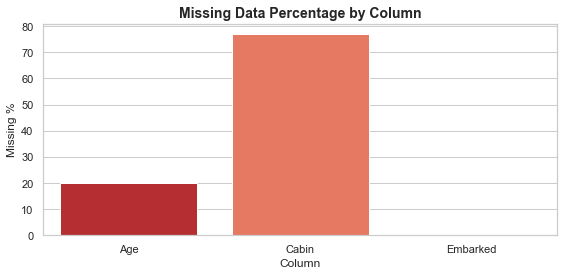

In [5]:
# Step 4: Check for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct.round(2)
})

print("=== Missing Values Summary ===")
print(missing_df[missing_df['Missing Values'] > 0])

# Visualize missing values
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_df[missing_df['Missing Values'] > 0].index,
            y=missing_df[missing_df['Missing Values'] > 0]['Percentage (%)'],
            palette='Reds_r')
plt.title('Missing Data Percentage by Column', fontsize=14, fontweight='bold')
plt.ylabel('Missing %')
plt.xlabel('Column')
plt.tight_layout()
plt.show()

## 5. Data Cleaning

In [6]:
# Step 5: Handle missing values

# Fill Age with median (robust to outliers)
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with mode (most common port)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column (too many missing values - 77%)
df.drop(columns=['Cabin'], inplace=True)

print("✅ Data cleaning complete!")
print(f"Missing values remaining: {df.isnull().sum().sum()}")
df.head()

✅ Data cleaning complete!
Missing values remaining: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## 6. Descriptive Statistics

In [7]:
# Step 6: Summary statistics
print("=== Descriptive Statistics ===")
df.describe(include='all').T

=== Descriptive Statistics ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,891.0,NaN,NaN,NaN,29.361582,13.019697,0.42,22.0,28.0,35.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 7. Survival Rate Analysis

Total Passengers : 891
Survived         : 342 (38.4%)
Did Not Survive  : 549 (61.6%)


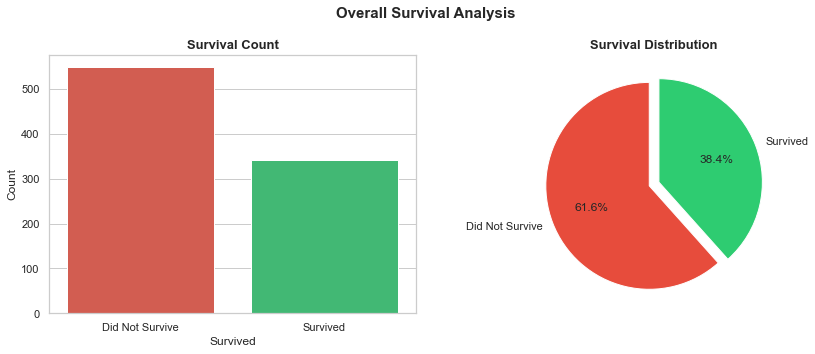

In [8]:
# Step 7: Overall survival rate
survived = df['Survived'].value_counts()
survival_rate = df['Survived'].mean() * 100

print(f"Total Passengers : {len(df)}")
print(f"Survived         : {survived[1]} ({survival_rate:.1f}%)")
print(f"Did Not Survive  : {survived[0]} ({100 - survival_rate:.1f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(x='Survived', data=df, palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Survival Count', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Did Not Survive', 'Survived'])
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie([survived[0], survived[1]], labels=['Did Not Survive', 'Survived'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Survival Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Overall Survival Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Survival by Gender

Survival Rate by Gender:
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64


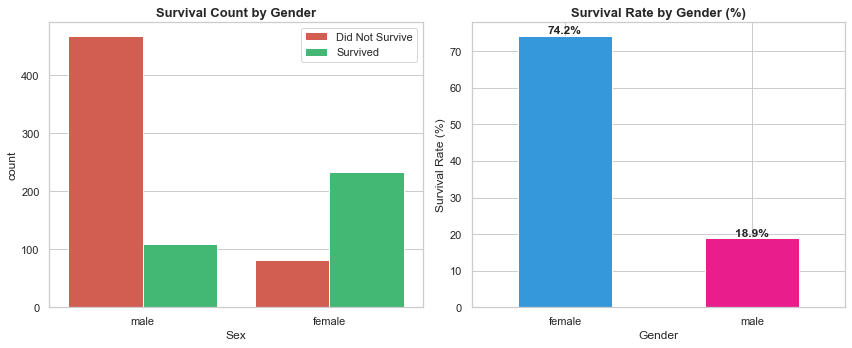


📌 Insight: Female passengers had a significantly higher survival rate than males.


In [9]:
# Step 8: Survival by gender
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
print("Survival Rate by Gender:")
print(gender_survival.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Sex', hue='Survived', data=df,
              palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Survival Count by Gender', fontsize=13, fontweight='bold')
axes[0].legend(['Did Not Survive', 'Survived'])

gender_survival.plot(kind='bar', color=['#3498db', '#e91e8c'], ax=axes[1], rot=0)
axes[1].set_title('Survival Rate by Gender (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_xlabel('Gender')
for i, v in enumerate(gender_survival):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("\n📌 Insight: Female passengers had a significantly higher survival rate than males.")

## 9. Survival by Passenger Class

Survival Rate by Passenger Class:
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


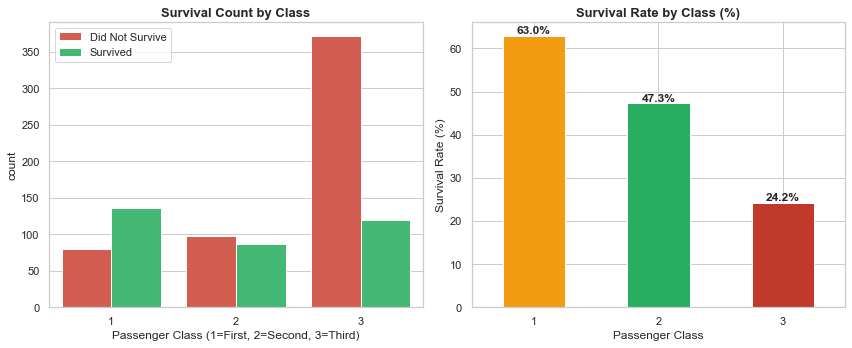


📌 Insight: 1st class passengers had the highest survival rate. 3rd class had the lowest.


In [10]:
# Step 9: Survival by Pclass
pclass_survival = df.groupby('Pclass')['Survived'].mean() * 100
print("Survival Rate by Passenger Class:")
print(pclass_survival.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Pclass', hue='Survived', data=df,
              palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Survival Count by Class', fontsize=13, fontweight='bold')
axes[0].legend(['Did Not Survive', 'Survived'])
axes[0].set_xlabel('Passenger Class (1=First, 2=Second, 3=Third)')

pclass_survival.plot(kind='bar', color=['#f39c12', '#27ae60', '#c0392b'],
                     ax=axes[1], rot=0)
axes[1].set_title('Survival Rate by Class (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_xlabel('Passenger Class')
for i, v in enumerate(pclass_survival):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("\n📌 Insight: 1st class passengers had the highest survival rate. 3rd class had the lowest.")

## 10. Age Distribution & Survival

Age - Mean: 29.7, Median: 28.0
Age Range: 0 to 80


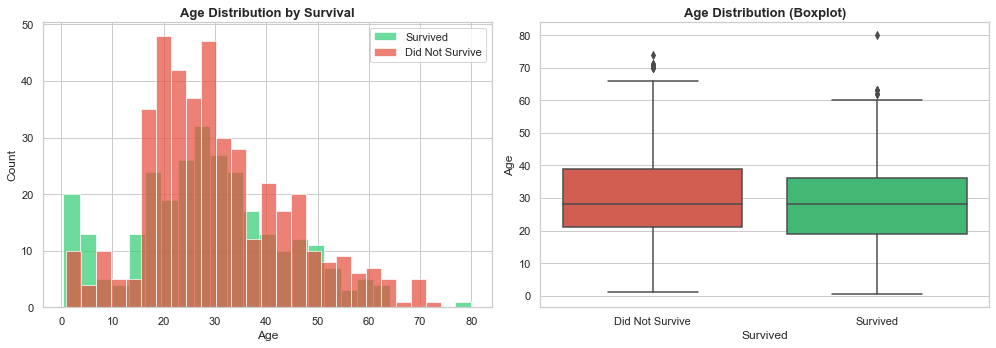


📌 Insight: Children (young ages) had a relatively higher chance of survival.


In [3]:
# Step 10: Age analysis
print(f"Age - Mean: {df['Age'].mean():.1f}, Median: {df['Age'].median():.1f}")
print(f"Age Range: {df['Age'].min():.0f} to {df['Age'].max():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
axes[0].hist(df[df['Survived']==1]['Age'], bins=25, alpha=0.7,
             color='#2ecc71', label='Survived')
axes[0].hist(df[df['Survived']==0]['Age'], bins=25, alpha=0.7,
             color='#e74c3c', label='Did Not Survive')
axes[0].set_title('Age Distribution by Survival', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
sns.boxplot(x='Survived', y='Age', data=df,
            palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_title('Age Distribution (Boxplot)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Did Not Survive', 'Survived'])

plt.tight_layout()
plt.show()
print("\n📌 Insight: Children (young ages) had a relatively higher chance of survival.")

## 11. Correlation Heatmap

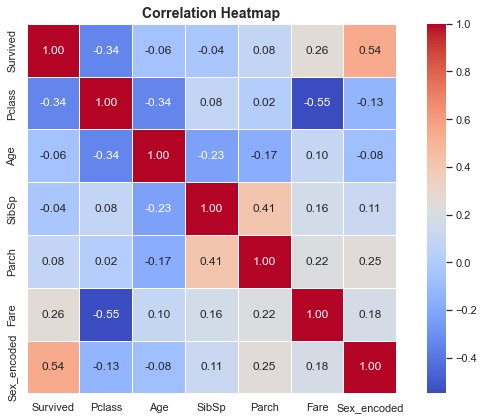


📌 Insight: Being female (Sex_encoded) and Fare paid are positively correlated with survival.
         Passenger class (Pclass) is negatively correlated — lower class = less likely to survive.


In [11]:
# Step 11: Correlation analysis
# Encode 'Sex' for correlation
df_corr = df.copy()
df_corr['Sex_encoded'] = df_corr['Sex'].map({'male': 0, 'female': 1})

num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_encoded']
corr_matrix = df_corr[num_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n📌 Insight: Being female (Sex_encoded) and Fare paid are positively correlated with survival.")
print("         Passenger class (Pclass) is negatively correlated — lower class = less likely to survive.")

## 12. Key Findings & Summary

| Finding | Detail |
|---|---|
| Overall Survival Rate | ~38% of passengers survived |
| Gender Impact | Women: ~74% survived; Men: ~19% survived |
| Class Impact | 1st class: ~63%; 2nd: ~47%; 3rd: ~24% |
| Age | Children had better survival chances |
| Fare | Higher fare correlates with higher survival |
| Missing Data | Age (20%), Cabin (77%), Embarked (0.2%) |

### Conclusion
The Titanic disaster was not random — survival was strongly influenced by **gender**, **social class**, and **age**. The 'women and children first' evacuation policy is clearly visible in the data. Wealthier passengers (higher Pclass, higher Fare) also had significantly better survival odds, likely due to better cabin locations and access to lifeboats.

---
*Internship Task 2 — CodeAlpha Data Analytics*